# Group Activity Recognition — Complete Self-Contained Notebook

Builds **all features from the raw `model_ready` files** using your exact feature code (so every
number matches your pipeline), with the **mutual-gaze** features added, then runs every analysis:

1. Build interaction features  ·  2. Build recognition features  *(both incl. gaze)*
3. Raw vs engineered  ·  4. Model comparison + confusion matrices (incl. Transformer)
5. Explainability  ·  6. Imbalance  ·  7. Stratification  ·  8. Mutual-gaze test

**How to run:** mount Drive (cell below), check `INPUT_DIR` inside the two build cells points to your
`ALL_MODEL_READY_FILES_IDENTITY_FIXED` folder, then run top-to-bottom. Use a **GPU runtime** for the
Transformer (Runtime → Change runtime type → GPU).

## 0 · Setup

In [1]:
# === SETUP ===
try:
    from google.colab import drive; drive.mount("/content/drive")
except Exception as e:
    print("drive mount skipped:", e)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings
from collections import Counter
warnings.filterwarnings("ignore"); np.seterr(all="ignore")
sns.set_theme(style="whitegrid", font_scale=1.0)
TEAL,AMBER,CORAL,INK,SLATE = "#1F7A8C","#F2A65A","#E07A5F","#0E2233","#9FB3BE"
plt.rcParams.update({"axes.edgecolor":SLATE,"axes.titleweight":"bold","figure.dpi":120})
print("setup done.")

Mounted at /content/drive
setup done.


## 1 · Build INTERACTION features  *(your exact code + gaze)*

Saves `INTERACTION_ENG2/interaction_eng_features.csv` + `..._tensors.npz`.
The 3 gaze columns (`head_antiface`, `head_colinear`, `head_facing_min`) are added in the head block.

In [ ]:
# CELL 1 (v2) — INTERACTION: proximity + head(OE) + hand(Xsens) features
import os, glob, re, gc
import numpy as np, pandas as pd

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR  ="/content/drive/MyDrive/thesis/data/INTERACTION_ENG2"
WINDOW_S,STRIDE_S,RESAMPLE_T=5.0,5.0,64
GROUP_TIERS=["label_Participant1_Participant2","label_Participant1_Participant3",
             "label_Participant2_Participant3","label_Whole_Group"]
OE_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyro","mag") for a in "xyz"]
XS_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyr","euler") for a in "xyz"]
POS=[f"Participant{p}_{a}" for p in(1,2,3) for a in "xyz"]
os.makedirs(OUT_DIR,exist_ok=True)

def discover(folder):
    g={}
    for p in glob.glob(os.path.join(folder,"group_*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(p))
        if m: g.setdefault(int(m.group(1)),{})[m.group(2)]=p
    return {k:v for k,v in sorted(g.items()) if all(s in v for s in("openearable","xsens","optitrack"))}

def load(path,timecol,cols):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df[timecol],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in cols:
        if c not in df.columns: df[c]=np.nan
        df[c]=pd.to_numeric(df[c],errors="coerce")
        df[c]=df[c].where(df[c].abs()<1e6, np.nan)        # drop sentinel/garbage
    return df

def xoff(oe,xs):
    g=np.arange(max(oe["t"].min(),5),oe["t"].max()-5,0.2)
    def samp(d,times):
        idx=np.clip(np.searchsorted(d["t"].values,times),0,len(d)-1)
        return d["label_Whole_Group"].fillna("NONE").astype(str).values[idx]
    rs=samp(oe,g); best=(0,-1)
    for o in np.arange(0,220,0.5):
        a=np.mean(rs==samp(xs,g+o))
        if a>best[1]: best=(o,a)
    return best[0]

def spec(sig,fs):
    sig=sig[np.isfinite(sig)]
    if len(sig)<8: return 0.0,0.0,0.0
    sig=sig-sig.mean()
    f=np.fft.rfftfreq(len(sig),1/fs); P=np.abs(np.fft.rfft(sig))**2
    if len(P)<2 or P[1:].sum()<=0: return 0.0,0.0,float(P.sum())
    dom=f[1:][np.argmax(P[1:])]; cent=(f[1:]*P[1:]).sum()/P[1:].sum()
    return float(dom),float(cent),float(P[1:].sum())

def circmean_deg(a):
    a=a[np.isfinite(a)]
    if len(a)==0: return 0.0
    r=np.deg2rad(a); return float(np.rad2deg(np.arctan2(np.sin(r).mean(),np.cos(r).mean())))

import numpy as np
from scipy.signal import welch

def feats(oe, xs, ot, ws, we):
    # Slice the windows exactly using the notebook's timestamp logic
    o = oe.iloc[np.searchsorted(oe["t"].values, ws):np.searchsorted(oe["t"].values, we)]
    x = xs.iloc[np.searchsorted(xs["t"].values, ws):np.searchsorted(xs["t"].values, we)]
    p = ot.iloc[np.searchsorted(ot["t"].values, ws):np.searchsorted(ot["t"].values, we)]

    fo = max(len(o) / WINDOW_S, 1)
    fx = max(len(x) / WINDOW_S, 1)
    grid = np.linspace(ws, we, RESAMPLE_T)
    row = {}

    # ---------------------------------------------------------
    # A. OPTITRACK POSITION & PROXIMITY (ENG2)
    # ---------------------------------------------------------
    P = {i: p[[f"Participant{i}_{a}" for a in "xyz"]].values for i in (1, 2, 3)}
    d = {(a, b): np.linalg.norm(P[a] - P[b], axis=1) for a, b in [(1, 2), (1, 3), (2, 3)]}
    D = np.stack(list(d.values()), 1)
    Ds = np.sort(D, 1) if len(p) > 0 else np.zeros((1, 3))

    with np.errstate(all="ignore"):
        row["dist_close_mean"] = np.nanmean(Ds[:, 0])
        row["dist_close_min"] = np.nanmin(Ds[:, 0])
        row["dist_mid_mean"] = np.nanmean(Ds[:, 1])
        row["dist_far_mean"] = np.nanmean(Ds[:, 2])
        row["dist_disp_mean"] = np.nanmean(D)
        row["dist_disp_std"] = np.nanstd(D)

    cen = (P[1] + P[2] + P[3]) / 3
    row["centroid_speed"] = np.nanmean(np.linalg.norm(np.gradient(cen, axis=0), axis=1)) * (len(p) / WINDOW_S) if len(p) > 1 else 0.0

    # ---------------------------------------------------------
    # B. BRING BACK INDIVIDUAL PARTICIPANT SPEEDS (From ENG)
    # ---------------------------------------------------------
    if len(p) > 1:
        fps_p = len(p) / WINDOW_S
        spd = {i: np.linalg.norm(np.gradient(P[i], axis=0), axis=1) * fps_p for i in (1, 2, 3)}
        spdm = np.sort([np.nanmean(spd[i]) for i in (1, 2, 3)])
    else:
        spdm = [0.0, 0.0, 0.0]
    row["speed_min"] = spdm[0]
    row["speed_mid"] = spdm[1]
    row["speed_max"] = spdm[2]

    # ---------------------------------------------------------
    # C. HEAD ORIENTATION & MOTION ENERGY (ENG + ENG2 hybrid)
    # ---------------------------------------------------------
    pitch, headg, hdom, hpow = [], [], [], []
    acc_stds, gyr_stds = [], []
    hmags_coord = {}

    for i in (1, 2, 3):
        acc = o[[f"p{i}_acc_{a}" for a in "xyz"]].values
        mag = o[[f"p{i}_mag_{a}" for a in "xyz"]].values
        gyr = o[[f"p{i}_gyro_{a}" for a in "xyz"]].values
        if len(acc):
            pitch.append(np.nanmean(np.degrees(np.arctan2(acc[:, 0], np.sqrt(acc[:, 1] ** 2 + acc[:, 2] ** 2)))))
            headg.append(circmean_deg(np.degrees(np.arctan2(mag[:, 1], mag[:, 0]))))

            acc_mag = np.linalg.norm(acc, axis=1)
            gyr_mag = np.linalg.norm(gyr, axis=1)
            dm, ct, pw = spec(gyr_mag, fo)
            hdom.append(dm)
            hpow.append(pw)

            # Extract raw motion standard deviations from high-performing ENG
            acc_stds.append(np.nanstd(acc_mag))
            gyr_stds.append(np.nanstd(gyr_mag))
            hmags_coord[i] = acc_mag

    row["head_pitch_mean"] = np.nanmean(pitch) if pitch else 0.0
    row["head_facing"] = np.mean([np.cos(np.deg2rad(headg[a] - headg[b])) for a, b in [(0, 1), (0, 2), (1, 2)]]) if len(headg) == 3 else 0.0
    _gd = np.array([np.cos(np.deg2rad(headg[a] - headg[b])) for a, b in [(0, 1), (0, 2), (1, 2)]]) if len(headg) == 3 else np.zeros(3)
    row["head_antiface"] = float(np.mean(np.clip(-_gd, 0, 1)))
    row["head_colinear"] = float(np.mean(np.abs(_gd)))
    row["head_facing_min"] = float(np.min(_gd))
    row["head_freq_mean"] = np.mean(hdom) if hdom else 0.0
    row["head_freq_max"] = np.max(hdom) if hdom else 0.0
    row["head_power_mean"] = np.log1p(np.mean(hpow)) if hpow else 0.0

    # Sort and add raw earable motion energy limits
    aE = np.sort(acc_stds) if acc_stds else [0.0, 0.0, 0.0]
    gE = np.sort(gyr_stds) if gyr_stds else [0.0, 0.0, 0.0]
    row["accE_min"], row["accE_mid"], row["accE_max"] = aE[0], aE[1], aE[2]
    row["gyrE_min"], row["gyrE_mid"], row["gyrE_max"] = gE[0], gE[1], gE[2]

    # Bring back cross-participant motion synchronization (move_coord)
    def cr(a, b):
        m = np.isfinite(a) & np.isfinite(b)
        if len(a) == 0 or len(b) == 0: return 0.0
        return 0.0 if (len(a[m]) < 3 or np.std(a[m]) < 1e-6 or np.std(b[m]) < 1e-6) else float(np.corrcoef(a[m], b[m])[0, 1])

    if all(i in hmags_coord and len(hmags_coord[i]) > 0 for i in (1, 2, 3)):
        row["move_coord"] = np.mean([cr(hmags_coord[1], hmags_coord[2]), cr(hmags_coord[1], hmags_coord[3]), cr(hmags_coord[2], hmags_coord[3])])
    else:
        row["move_coord"] = 0.0

    # ---------------------------------------------------------
    # D. XSENS HAND KINEMATICS (ENG2)
    # ---------------------------------------------------------
    xdom, xpow, ovar, hmag = [], [], [], []
    for i in (1, 2, 3):
        acc = x[[f"p{i}_acc_{a}" for a in "xyz"]].values
        eul = x[[f"p{i}_euler_{a}" for a in "xyz"]].values
        if len(acc):
            mag = np.linalg.norm(acc, axis=1)
            dm, ct, pw = spec(mag, fx)
            xdom.append(dm)
            xpow.append(pw)
            ovar.append(np.nanmean(np.nanstd(eul, axis=0)))
            hmag.append(np.interp(grid, x["t"].values, mag))

    row["hand_freq_mean"] = np.mean(xdom) if xdom else 0.0
    row["hand_freq_max"] = np.max(xdom) if xdom else 0.0
    row["hand_power_mean"] = np.log1p(np.mean(xpow)) if xpow else 0.0
    row["hand_orient_var"] = np.mean(ovar) if ovar else 0.0
    if len(hmag) == 3:
        row["hand_coord"] = np.mean([cr(hmag[0], hmag[1]), cr(hmag[0], hmag[2]), cr(hmag[1], hmag[2])])
    else:
        row["hand_coord"] = 0.0

    # Generate the 3-channel sequence distance matrix tensor required by build()
    if len(p) > 1:
        pt = p["t"].values
        ten = np.stack([np.interp(grid, pt, Ds[:, 0]), np.interp(grid, pt, Ds[:, 1]), np.interp(grid, pt, Ds[:, 2])], 1).astype(np.float32)
    else:
        ten = np.zeros((RESAMPLE_T, 3), np.float32)

    row = {k: (0.0 if (v is None or not np.isfinite(v)) else v) for k, v in row.items()}
    return row, ten

def build():
    feats_,tens,Y,G=[],[],[],[]
    for g,paths in groups.items():
        oe=load(paths["openearable"],"video_time_s",OE_COLS)
        xs=load(paths["xsens"],"time_s",XS_COLS)
        ot=load(paths["optitrack"],"video_time_s",POS)
        xs["t"]-=xoff(oe,xs)
        lo=max(oe["t"].min(),xs["t"].min(),ot["t"].min()); hi=min(oe["t"].max(),xs["t"].max(),ot["t"].max())
        rt=oe["t"].values
        inter=np.zeros(len(oe),bool)
        for col in GROUP_TIERS:
            if col in oe.columns:
                inter|=oe[col].notna().values & (oe[col].astype(str).str.strip()!="").values
        n0=len(Y)
        for ws in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S):
            we=ws+WINDOW_S; m=(rt>=ws)&(rt<we)
            if m.sum()==0: continue
            lab="interaction" if inter[m].mean()>=0.5 else "non_interaction"
            row,ten=feats(oe,xs,ot,ws,we); row["group"]=g
            feats_.append(row); tens.append(ten); Y.append(lab); G.append(g)
        print(f"  group {g}: {len(Y)-n0} windows"); del oe,xs,ot; gc.collect()
    return pd.DataFrame(feats_).assign(label=Y), np.stack(tens), np.array(Y), np.array(G)

groups=discover(INPUT_DIR); print("Groups:",list(groups))
F,X,Y,G=build()
F.to_csv(f"{OUT_DIR}/interaction_eng_features.csv",index=False)
np.savez_compressed(f"{OUT_DIR}/interaction_eng_tensors.npz",X=X,y=Y,groups=G)
print(f"\n{X.shape} | {pd.Series(Y).value_counts().to_dict()}")
print("features:",[c for c in F.columns if c not in('group','label')])

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
  group 1: 366 windows
  group 2: 524 windows
  group 3: 527 windows
  group 5: 661 windows
  group 6: 187 windows
  group 7: 569 windows
  group 8: 457 windows
  group 9: 475 windows
  group 10: 283 windows

(4049, 64, 3) | {'non_interaction': 2208, 'interaction': 1841}
features: ['dist_close_mean', 'dist_close_min', 'dist_mid_mean', 'dist_far_mean', 'dist_disp_mean', 'dist_disp_std', 'centroid_speed', 'speed_min', 'speed_mid', 'speed_max', 'head_pitch_mean', 'head_facing', 'head_antiface', 'head_colinear', 'head_facing_min', 'head_freq_mean', 'head_freq_max', 'head_power_mean', 'accE_min', 'accE_mid', 'accE_max', 'gyrE_min', 'gyrE_mid', 'gyrE_max', 'move_coord', 'hand_freq_mean', 'hand_freq_max', 'hand_power_mean', 'hand_orient_var', 'hand_coord']


## 2 · Build RECOGNITION features  *(your exact code + gaze)*

Saves `RECOGNITION_ENG2/recognition_fixed_features.csv` (+ labeled) + tensors, with gaze columns.

In [ ]:
# CELL 1 — RECOGNITION v2: proximity + LOCATION + CENTER + head + hand, 3 classes
import os, glob, re, gc, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore"); np.seterr(all="ignore")

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR  ="/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2"
WINDOW_S,STRIDE_S,RESAMPLE_T=5.0,5.0,64
LABEL_TIER="label_Whole_Group"
KEEP={"conversation","co_building","co_merging"}
os.makedirs(OUT_DIR,exist_ok=True)
OE_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyro","mag") for a in "xyz"]
XS_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyr","euler") for a in "xyz"]
POS=[f"Participant{p}_{a}" for p in(1,2,3) for a in "xyz"]

CLASS_SETS={
 "co_building":{"co_building_subpiece","co_building_piece","building_subpiece_together","building_subpiece"},
 "co_merging":{"co_merging_subpiece","merging_subpiece"},
 "conversation":{"task_operational_convo","task_related_convo","task_social_convo","task_related_social_convo","non_task_convo"},
}
def mapL(label):
    if pd.isna(label) or str(label).strip()=="": return ""
    parts=[str(p).strip().lower() for p in re.split(r"[+|/]",str(label))]
    for cls,names in CLASS_SETS.items():
        if any(p in names for p in parts): return cls
    return ""

def discover(folder):
    g={}
    for p in glob.glob(os.path.join(folder,"group_*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(p))
        if m: g.setdefault(int(m.group(1)),{})[m.group(2)]=p
    return {k:v for k,v in sorted(g.items()) if all(s in v for s in("openearable","xsens","optitrack"))}

def load(path,timecol,cols):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df[timecol],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in cols:
        if c not in df.columns: df[c]=np.nan
        df[c]=pd.to_numeric(df[c],errors="coerce"); df[c]=df[c].where(df[c].abs()<1e6,np.nan)
    return df

def xoff(oe,xs):
    g=np.arange(max(oe["t"].min(),5),oe["t"].max()-5,0.2)
    def samp(d,times):
        idx=np.clip(np.searchsorted(d["t"].values,times),0,len(d)-1)
        return d["label_Whole_Group"].fillna("NONE").astype(str).values[idx]
    rs=samp(oe,g); best=(0,-1)
    for o in np.arange(0,220,0.5):
        a=np.mean(rs==samp(xs,g+o))
        if a>best[1]: best=(o,a)
    return best[0]

def spec(sig,fs):
    sig=sig[np.isfinite(sig)]
    if len(sig)<8: return 0.0,0.0
    sig=sig-sig.mean(); f=np.fft.rfftfreq(len(sig),1/fs); P=np.abs(np.fft.rfft(sig))**2
    if len(P)<2 or P[1:].sum()<=0: return 0.0,float(P.sum())
    return float(f[1:][np.argmax(P[1:])]),float(P[1:].sum())

def circmean(a):
    a=a[np.isfinite(a)]
    return 0.0 if len(a)==0 else float(np.rad2deg(np.arctan2(np.sin(np.deg2rad(a)).mean(),np.cos(np.deg2rad(a)).mean())))

def mn(v): return float(np.mean(v)) if len(v) > 0 else 0.0
def mx(v): return float(np.max(v)) if len(v) > 0 else 0.0

def feats(oe, xs, ot, ws, we, home):
    o = oe.iloc[np.searchsorted(oe["t"].values, ws):np.searchsorted(oe["t"].values, we)]
    x = xs.iloc[np.searchsorted(xs["t"].values, ws):np.searchsorted(xs["t"].values, we)]
    p = ot.iloc[np.searchsorted(ot["t"].values, ws):np.searchsorted(ot["t"].values, we)]

    fo = max(len(o) / WINDOW_S, 1)
    fx = max(len(x) / WINDOW_S, 1)
    grid = np.linspace(ws, we, RESAMPLE_T)
    row = {}

    # 1. PROXIMITY
    P = {i: p[[f"Participant{i}_{a}" for a in "xyz"]].values for i in (1, 2, 3)}
    d = {(a, b): np.linalg.norm(P[a] - P[b], axis=1) for a, b in [(1, 2), (1, 3), (2, 3)]}
    D = np.stack(list(d.values()), 1)
    Ds = np.sort(D, 1) if len(p) > 0 else np.zeros((1, 3))
    row["dist_close_mean"] = np.nanmean(Ds[:, 0])
    row["dist_mid_mean"] = np.nanmean(Ds[:, 1])
    row["dist_far_mean"] = np.nanmean(Ds[:, 2])
    row["dist_disp_std"] = np.nanstd(D)

    cen = (P[1] + P[2] + P[3]) / 3
    row["centroid_speed"] = np.nanmean(np.linalg.norm(np.gradient(cen, axis=0), axis=1)) * (len(p) / WINDOW_S) if len(p) > 1 else 0.0

    # 2. OPTITRACK SPEED METRICS (Injected from successful ENG)
    if len(p) > 1:
        fps_p = len(p) / WINDOW_S
        spd = {i: np.linalg.norm(np.gradient(P[i], axis=0), axis=1) * fps_p for i in (1, 2, 3)}
        spdm = np.sort([np.nanmean(spd[i]) for i in (1, 2, 3)])
    else:
        spdm = [0.0, 0.0, 0.0]
    row["speed_min"] = spdm[0]
    row["speed_mid"] = spdm[1]
    row["speed_max"] = spdm[2]

    # 3. LOCATION / HOME CUES (From ENG2)
    far_safe = row["dist_far_mean"] if np.isfinite(row["dist_far_mean"]) else 0.0
    fh = []
    for i in (1, 2, 3):
        if len(P[i]) > 0 and np.isfinite(home[i]).all():
            fh.append(np.nanmean(np.linalg.norm(P[i] - home[i], axis=1)))
    if len(fh) > 0:
        row["fromhome_mean"] = float(np.mean(fh))
        row["fromhome_min"] = float(np.min(fh))
        row["converge_ratio"] = float(np.min(fh) / (far_safe + 0.5))
    else:
        row["fromhome_mean"] = row["fromhome_min"] = row["converge_ratio"] = 0.0

    ctr = []
    for i in (1, 2, 3):
        if len(P[i]) > 0:
            ctr.append(np.nanmean(np.sqrt(P[i][:, 0] ** 2 + P[i][:, 2] ** 2)))
    row["center_dist_centroid"] = np.nanmean(np.sqrt(cen[:, 0] ** 2 + cen[:, 2] ** 2)) if len(p) > 0 else 0.0
    row["center_dist_min"] = float(np.min(ctr)) if len(ctr) > 0 else 0.0

    # 4. HEAD / GAZE & RAW MOTION ENERGY (Hybrid ENG + ENG2)
    pitch, headg, hdom, hpow, hgrid = [], [], [], [], []
    acc_stds, gyr_stds = [], []
    hmags_coord = {}

    for i in (1, 2, 3):
        acc = o[[f"p{i}_acc_{a}" for a in "xyz"]].values
        mag = o[[f"p{i}_mag_{a}" for a in "xyz"]].values
        gyr = o[[f"p{i}_gyro_{a}" for a in "xyz"]].values
        if len(acc) > 0:
            pitch.append(np.nanmean(np.degrees(np.arctan2(acc[:, 0], np.sqrt(acc[:, 1] ** 2 + acc[:, 2] ** 2)))))
            headg.append(circmean(np.degrees(np.arctan2(mag[:, 1], mag[:, 0]))))
            am = np.linalg.norm(acc, axis=1)
            gm = np.linalg.norm(gyr, axis=1)
            dm, pw = spec(gm, fo)
            hdom.append(dm)
            hpow.append(pw)
            hgrid.append(np.interp(grid, o["t"].values, gm))

            # Grabbing raw motion standard deviations (From ENG)
            acc_stds.append(np.nanstd(am))
            gyr_stds.append(np.nanstd(gm))
            hmags_coord[i] = am

    row["head_pitch_mean"] = mn(pitch)
    if len(headg) == 3:
        row["head_facing"] = np.mean([np.cos(np.deg2rad(headg[a] - headg[b])) for a, b in [(0, 1), (0, 2), (1, 2)]])
    else:
        row["head_facing"] = 0.0

    _gd = np.array([np.cos(np.deg2rad(headg[a]-headg[b])) for a,b in [(0,1),(0,2),(1,2)]]) if len(headg)==3 else np.zeros(3)
    row["head_antiface"] = float(np.mean(np.clip(-_gd, 0, 1)))
    row["head_colinear"] = float(np.mean(np.abs(_gd)))
    row["head_facing_min"] = float(np.min(_gd))
    row["head_freq_mean"] = mn(hdom)
    row["head_freq_max"] = mx(hdom)
    row["head_power_mean"] = np.log1p(mn(hpow))

    # Add ENG energy limits
    aE = np.sort(acc_stds) if acc_stds else [0.0, 0.0, 0.0]
    gE = np.sort(gyr_stds) if gyr_stds else [0.0, 0.0, 0.0]
    row["accE_min"], row["accE_mid"], row["accE_max"] = aE[0], aE[1], aE[2]
    row["gyrE_min"], row["gyrE_mid"], row["gyrE_max"] = gE[0], gE[1], gE[2]

    def cr(a, b):
        m = np.isfinite(a) & np.isfinite(b)
        if len(a) == 0 or len(b) == 0: return 0.0
        return 0.0 if (len(a[m]) < 3 or np.std(a[m]) < 1e-6 or np.std(b[m]) < 1e-6) else float(np.corrcoef(a[m], b[m])[0, 1])

    if all(i in hmags_coord and len(hmags_coord[i]) > 0 for i in (1, 2, 3)):
        row["move_coord"] = np.mean([cr(hmags_coord[1], hmags_coord[2]), cr(hmags_coord[1], hmags_coord[3]), cr(hmags_coord[2], hmags_coord[3])])
    else:
        row["move_coord"] = 0.0

    # 5. HAND KINEMATICS (Xsens)
    xdom, xpow, ovar, xgrid = [], [], [], []
    for i in (1, 2, 3):
        acc = x[[f"p{i}_acc_{a}" for a in "xyz"]].values
        eul = x[[f"p{i}_euler_{a}" for a in "xyz"]].values
        if len(acc) > 0:
            am = np.linalg.norm(acc, axis=1)
            dm, pw = spec(am, fx)
            xdom.append(dm)
            xpow.append(pw)
            ovar.append(np.nanmean(np.nanstd(eul, axis=0)))
            xgrid.append(np.interp(grid, x["t"].values, am))

    row["hand_freq_mean"] = mn(xdom)
    row["hand_freq_max"] = mx(xdom)
    row["hand_power_mean"] = np.log1p(mn(xpow))
    row["hand_orient_var"] = mn(ovar)
    if len(xgrid) == 3:
        row["hand_coord"] = np.mean([cr(xgrid[0], xgrid[1]), cr(xgrid[0], xgrid[2]), cr(xgrid[1], xgrid[2])])
    else:
        row["hand_coord"] = 0.0

    # TENSOR RECONSTRUCTION (5 channels for deep learning)
    dch = [np.interp(grid, p["t"].values, Ds[:, k]) if len(p) > 1 else np.zeros(RESAMPLE_T) for k in range(3)]
    head_ch = np.mean(hgrid, 0) if len(hgrid) == 3 else np.zeros(RESAMPLE_T)
    hand_ch = np.mean(xgrid, 0) if len(xgrid) == 3 else np.zeros(RESAMPLE_T)
    ten = np.stack(dch + [head_ch, hand_ch], 1).astype(np.float32)

    row = {k: (0.0 if (v is None or not np.isfinite(v)) else v) for k, v in row.items()}
    return row, ten

def build(mode):
    feats_,tens,Y,G=[],[],[],[]
    for g,paths in groups.items():
        oe=load(paths["openearable"],"video_time_s",OE_COLS)
        xs=load(paths["xsens"],"time_s",XS_COLS); ot=load(paths["optitrack"],"video_time_s",POS)
        xs["t"]-=xoff(oe,xs)
        lo=max(oe["t"].min(),xs["t"].min(),ot["t"].min()); hi=min(oe["t"].max(),xs["t"].max(),ot["t"].max())
        rt=oe["t"].values
        Pfull={i:ot[[f"Participant{i}_{a}" for a in "xyz"]].values for i in(1,2,3)}
        home={i:np.nanmedian(Pfull[i],axis=0) for i in(1,2,3)}
        uniq={u:mapL(u) for u in oe[LABEL_TIER].dropna().astype(str).unique()}
        rc=oe[LABEL_TIER].astype(str).map(uniq).fillna("").values
        valid=np.isin(rc,list(KEEP))
        if mode=="fixed":
            wins=[(w,w+WINDOW_S) for w in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S)]
        else:
            codes=pd.Series(rc).astype("category").cat.codes.values
            chg=np.where(np.diff(codes)!=0)[0]+1; b=[0]+list(chg)+[len(oe)]; wins=[]
            for i in range(len(b)-1):
                st,et=rt[b[i]],rt[min(b[i+1],len(rt)-1)]
                if et-st>=0.5 and st>=lo and et<=hi: wins.append((st,et))
        n0=len(Y)
        for ws,we in wins:
            m=(rt>=ws)&(rt<we)&valid
            if m.sum()==0: continue
            lab=pd.Series(rc[m]).mode().iloc[0]
            row,ten=feats(oe,xs,ot,ws,we,home); row["group"]=g
            feats_.append(row); tens.append(ten); Y.append(lab); G.append(g)
        print(f"  group {g} [{mode}]: {len(Y)-n0} windows"); del oe,xs,ot; gc.collect()
    return pd.DataFrame(feats_).assign(label=Y), np.stack(tens), np.array(Y), np.array(G)

groups=discover(INPUT_DIR); print("Groups:",list(groups))
for mode in ["fixed","labeled"]:
    F,X,Y,G=build(mode)
    F.to_csv(f"{OUT_DIR}/recognition_{mode}_features.csv",index=False)
    np.savez_compressed(f"{OUT_DIR}/recognition_{mode}_tensors.npz",X=X,y=Y,groups=G)
    print(f"{mode}: {X.shape} | {pd.Series(Y).value_counts().to_dict()}\n")
print("done")

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
  group 1 [fixed]: 113 windows
  group 2 [fixed]: 160 windows
  group 3 [fixed]: 89 windows
  group 5 [fixed]: 83 windows
  group 6 [fixed]: 51 windows
  group 7 [fixed]: 71 windows
  group 8 [fixed]: 166 windows
  group 9 [fixed]: 51 windows
  group 10 [fixed]: 22 windows
fixed: (806, 64, 5) | {'co_building': 342, 'conversation': 304, 'co_merging': 160}

  group 1 [labeled]: 16 windows
  group 2 [labeled]: 12 windows
  group 3 [labeled]: 15 windows
  group 5 [labeled]: 6 windows
  group 6 [labeled]: 5 windows
  group 7 [labeled]: 15 windows
  group 8 [labeled]: 25 windows
  group 9 [labeled]: 12 windows
  group 10 [labeled]: 6 windows
labeled: (112, 64, 5) | {'conversation': 72, 'co_building': 29, 'co_merging': 11}

done


## 3 · Load built features + evaluation harness

In [3]:
# === LOAD + HARNESS  (TRUE raw baseline from all 3 raw sensors: OE + OT + Xsens) ===
import os, glob, re, gc
import numpy as np, pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import LeaveOneGroupOut, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from collections import Counter

RAW_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
INT_DIR="/content/drive/MyDrive/thesis/data/INTERACTION_ENG"
REC_DIR="/content/drive/MyDrive/thesis/data/RECOGNITION_ENG"
ENG_CSV ={"interaction":f"{INT_DIR}/interaction_eng_features.csv", "recognition":f"{REC_DIR}/recognition_fixed_features.csv"}
CLASSES ={"interaction":["non_interaction","interaction"], "recognition":["co_building","co_merging","conversation"]}
GROUPS=[1,2,3,5,6,7,8,9,10]; WIN=5.0
GROUP_TIERS=["label_Participant1_Participant2","label_Participant1_Participant3","label_Participant2_Participant3","label_Whole_Group"]

OE_CH=[f"p{i}_{s}_{a}" for i in (1,2,3) for s in ("acc","gyro","mag") for a in "xyz"]   # 27 raw OE
OT_CH=[f"Participant{i}_{a}" for i in (1,2,3) for a in "xyz"]                            # 9 raw OT
XS_CH=[f"p{i}_{s}_{a}" for i in (1,2,3) for s in ("acc","gyr","euler") for a in "xyz"]   # 27 raw Xsens

TYPO={"object_handiver":"object_handover","nspecting_pieces":"inspecting_pieces",
      "returning_target_image_tr":"returning_target_image","carriyng_thray_to_central_table":"carrying_tray_to_central_table"}
CLASS_SETS={"co_building":{"co_building_subpiece","co_building_piece","building_subpiece_together","building_subpiece"},
            "co_merging":{"co_merging_subpiece","merging_subpiece"},
            "conversation":{"task_operational_convo","task_related_convo","task_social_convo","task_related_social_convo","non_task_convo"}}

def _norm(s): s=str(s).strip().lower(); return TYPO.get(s,s)
def to_rec_class(label):
    if pd.isna(label): return None
    parts=[_norm(p) for p in re.split(r"[+|/]",str(label))]
    for cls,names in CLASS_SETS.items():
        if any(p in names for p in parts): return cls
    return None

def _find(g,s):
    c=glob.glob(os.path.join(RAW_DIR,f"group_{g}_{s}_model_ready.csv")); return c[0] if c else None

def _stats(a):
    return None if len(a)==0 else np.concatenate([np.nanmean(a,0),np.nanstd(a,0),np.nanmin(a,0),np.nanmax(a,0)])

def xoff_fast(oe, xs):
    """Calculates time alignment offset for raw Xsens data"""
    g = np.arange(max(oe["video_time_s"].min(), 5), oe["video_time_s"].max()-5, 0.5)
    def samp(d, tcol, times):
        idx = np.clip(np.searchsorted(d[tcol].values, times), 0, len(d)-1)
        return d["label_Whole_Group"].fillna("NONE").astype(str).values[idx]
    rs = samp(oe, "video_time_s", g); best = (0, -1)
    for o in np.arange(0, 220, 0.5):
        a = np.mean(rs == samp(xs, "time_s", g+o))
        if a > best[1]: best = (o, a)
    return best[0]

def build_raw_all():
    """TRUE raw baseline: per-channel mean/std/min/max of raw OE + OT + Xsens signals."""
    INT,REC=[],[]
    for g in GROUPS:
        oef, otf, xsf = _find(g,"openearable"), _find(g,"optitrack"), _find(g,"xsens")
        if not oef or not otf or not xsf: continue

        oe = pd.read_csv(oef, low_memory=False)
        ot = pd.read_csv(otf, low_memory=False)
        xs = pd.read_csv(xsf, low_memory=False)

        if "video_time_s" not in oe or "video_time_s" not in ot or "time_s" not in xs: continue

        # Align Xsens time
        xs["time_s"] = pd.to_numeric(xs["time_s"], errors="coerce")
        xs = xs.dropna(subset=["time_s"]).sort_values("time_s").reset_index(drop=True)
        oe["video_time_s"] = pd.to_numeric(oe["video_time_s"], errors="coerce")
        oe = oe.dropna(subset=["video_time_s"]).sort_values("video_time_s").reset_index(drop=True)

        offset = xoff_fast(oe, xs)
        xs["t_aligned"] = xs["time_s"] - offset

        oet, ott, xst = oe["video_time_s"].values, ot["video_time_s"].values, xs["t_aligned"].values
        oeX = oe.reindex(columns=OE_CH).apply(pd.to_numeric, errors='coerce').values
        otX = ot.reindex(columns=OT_CH).apply(pd.to_numeric, errors='coerce').values
        xsX = xs.reindex(columns=XS_CH).apply(pd.to_numeric, errors='coerce').values

        gt=[c for c in GROUP_TIERS if c in oe.columns]; wg=oe["label_Whole_Group"] if "label_Whole_Group" in oe else None

        lo = max(np.nanmin(oet), np.nanmin(ott), np.nanmin(xst))
        hi = min(np.nanmax(oet), np.nanmax(ott), np.nanmax(xst))
        t = lo

        while t <= hi - WIN + 1e-9:
            moe = (oet >= t) & (oet < t + WIN)
            mot = (ott >= t) & (ott < t + WIN)
            mxs = (xst >= t) & (xst < t + WIN)

            if moe.sum() == 0 or mot.sum() == 0 or mxs.sum() == 0:
                t += WIN; continue

            so, st, sx = _stats(oeX[moe]), _stats(otX[mot]), _stats(xsX[mxs])
            if so is None or st is None or sx is None:
                t += WIN; continue

            feat = list(so) + list(st) + list(sx)
            active = oe.loc[moe, gt].notna().any(axis=1).mean() if gt else 0
            INT.append([g, "interaction" if active >= 0.5 else "non_interaction"] + feat)

            if wg is not None:
                lbls = [x for x in (to_rec_class(v) for v in wg[moe].dropna()) if x]
                if lbls: REC.append([g, Counter(lbls).most_common(1)[0][0]] + feat)
            t += WIN
        print(f"Group {g} raw 3-sensor baseline extracted...")
        del oe, ot, xs; gc.collect()

    cols = ["group", "label"] + [f"raw{i}" for i in range(4 * (len(OE_CH) + len(OT_CH) + len(XS_CH)))]
    return pd.DataFrame(INT, columns=cols), pd.DataFrame(REC, columns=cols)

print("building TRUE raw baseline from raw sensor channels (OpenEarable + OptiTrack + Xsens)...")
RAW_INT, RAW_REC = build_raw_all()

DATA={("interaction","eng"):pd.read_csv(ENG_CSV["interaction"]), ("interaction","raw"):RAW_INT,
      ("recognition","eng"):pd.read_csv(ENG_CSV["recognition"]), ("recognition","raw"):RAW_REC}

for (task,kind),df in DATA.items():
    n=len([c for c in df.columns if c not in ("group","label")])
    bal=dict(Counter(df[df["label"].isin(CLASSES[task])]["label"]))
    print(f"{task:12s} {kind}: {len(df):5d} win | {n:4d} feat | {bal}")

def prep(df,classes):
    df=df[df["label"].isin(classes)].reset_index(drop=True)
    feats=[c for c in df.columns if c not in ("group","label")]
    return df[feats].fillna(0).values, df["label"].values, df["group"].values, feats

def model(name):
    if name=="LogReg": return make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,class_weight="balanced"))
    return make_pipeline(StandardScaler(),RandomForestClassifier(n_estimators=400,class_weight="balanced",random_state=0))

def splitter(cv): return LeaveOneGroupOut() if cv=="logo" else StratifiedGroupKFold(5,shuffle=True,random_state=0)

def run(df, classes, name, cv="logo"):
    df=df[df["label"].isin(classes)].reset_index(drop=True)
    feats=[c for c in df.columns if c not in ("group","label")]
    X=df[feats].apply(pd.to_numeric,errors="coerce").values; y=df["label"].values; g=df["group"].values
    per_fold=[]; pt,pp=[],[]
    for tr,te in splitter(cv).split(X,y,g):
        clf=(LogisticRegression(max_iter=2000,class_weight="balanced") if name=="LogReg"
             else RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",random_state=0,n_jobs=-1))
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),clf)
        pipe.fit(X[tr],y[tr]); p=pipe.predict(X[te])
        per_fold.append((accuracy_score(y[te],p),f1_score(y[te],p,average="macro",zero_division=0)))
        pt+=list(y[te]); pp+=list(p)
    acc,mf=np.mean(per_fold,0)
    return np.array(pt),np.array(pp),acc,mf

print("harness ready (raw = 3 raw channels, engineered = your hybrid features).")

building TRUE raw baseline from raw sensor channels (OpenEarable + OptiTrack + Xsens)...
Group 1 raw 3-sensor baseline extracted...
Group 2 raw 3-sensor baseline extracted...
Group 3 raw 3-sensor baseline extracted...
Group 5 raw 3-sensor baseline extracted...
Group 6 raw 3-sensor baseline extracted...
Group 7 raw 3-sensor baseline extracted...
Group 8 raw 3-sensor baseline extracted...
Group 9 raw 3-sensor baseline extracted...
Group 10 raw 3-sensor baseline extracted...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/thesis/data/RECOGNITION_ENG/recognition_fixed_features.csv'

In [4]:
import pandas as pd
import os

paths = {
    "INTERACTION_ENG": "/content/drive/MyDrive/thesis/data/INTERACTION_ENG/interaction_eng_features.csv",
    "INTERACTION_ENG2": "/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/interaction_eng_features.csv",
}

for name, path in paths.items():
    print("\n" + "="*80)
    print(name)
    print("="*80)

    if not os.path.exists(path):
        print("File not found:", path)
        continue

    F = pd.read_csv(path)
    features = [c for c in F.columns if c not in ["group", "label"]]

    print("Shape:", F.shape)
    print("Number of features:", len(features))
    print("\nAll features:")
    for c in features:
        print(" -", c)

    xsens_like = [
        c for c in features
        if any(k in c.lower() for k in ["xsens", "hand", "euler", "orient", "gyr"])
    ]

    print("\nPossible Xsens-related features:")
    if xsens_like:
        for c in xsens_like:
            print(" -", c)
    else:
        print("No obvious Xsens-related features found.")


INTERACTION_ENG
Shape: (4372, 19)
Number of features: 17

All features:
 - dist_close_mean
 - dist_close_min
 - dist_mid_mean
 - dist_far_mean
 - dist_disp_mean
 - dist_disp_std
 - speed_min
 - speed_mid
 - speed_max
 - centroid_speed
 - accE_min
 - accE_mid
 - accE_max
 - gyrE_min
 - gyrE_mid
 - gyrE_max
 - move_coord

Possible Xsens-related features:
 - gyrE_min
 - gyrE_mid
 - gyrE_max

INTERACTION_ENG2
Shape: (4049, 32)
Number of features: 30

All features:
 - dist_close_mean
 - dist_close_min
 - dist_mid_mean
 - dist_far_mean
 - dist_disp_mean
 - dist_disp_std
 - centroid_speed
 - speed_min
 - speed_mid
 - speed_max
 - head_pitch_mean
 - head_facing
 - head_antiface
 - head_colinear
 - head_facing_min
 - head_freq_mean
 - head_freq_max
 - head_power_mean
 - accE_min
 - accE_mid
 - accE_max
 - gyrE_min
 - gyrE_mid
 - gyrE_max
 - move_coord
 - hand_freq_mean
 - hand_freq_max
 - hand_power_mean
 - hand_orient_var
 - hand_coord

Possible Xsens-related features:
 - gyrE_min
 - gyrE_mid

## 4 · Raw vs engineered features (LogReg · RF, LOGO)

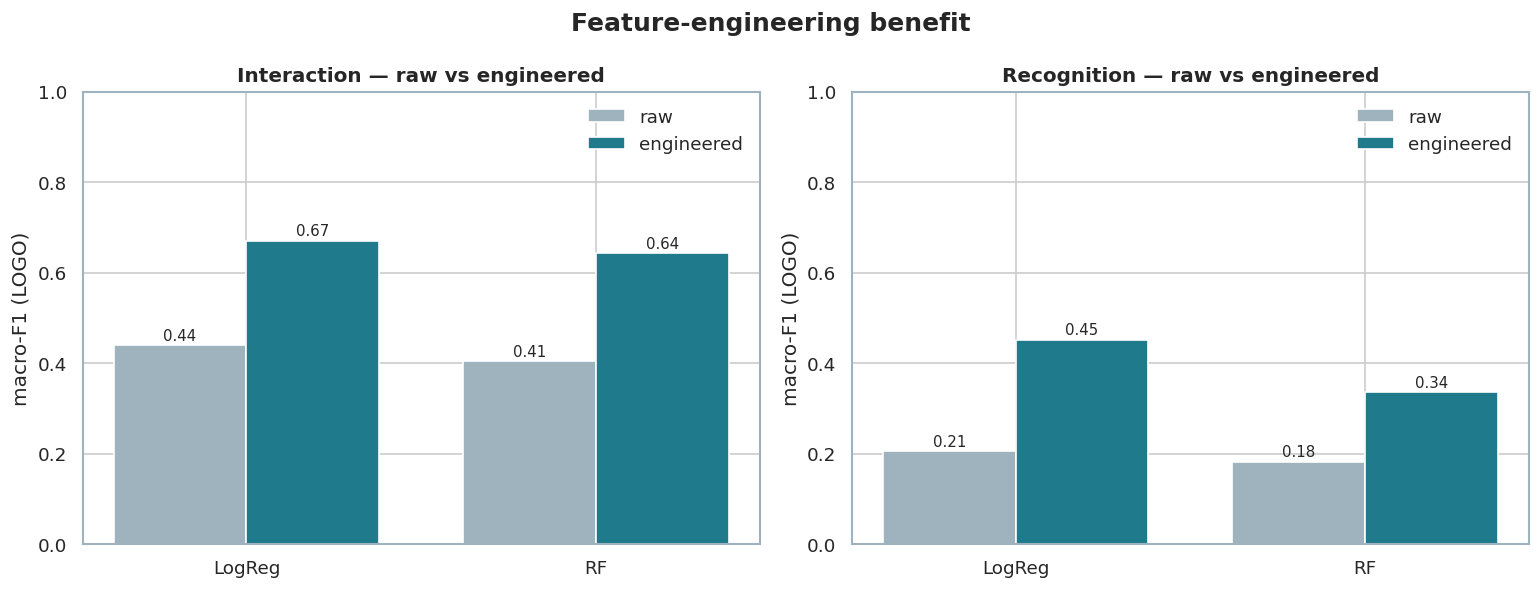

In [ ]:
# === RAW vs ENGINEERED ===
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,task in zip(axes,["interaction","recognition"]):
    names=["LogReg","RF"]; raw_v,eng_v=[],[]
    for name in names:
        _,_,_,fr=run(DATA[(task,"raw")],CLASSES[task],name); _,_,_,fe=run(DATA[(task,"eng")],CLASSES[task],name)
        raw_v.append(fr); eng_v.append(fe)
    xp=np.arange(len(names)); w=0.38
    ax.bar(xp-w/2,raw_v,w,label="raw",color=SLATE); ax.bar(xp+w/2,eng_v,w,label="engineered",color=TEAL)
    for i in range(len(names)):
        ax.text(i-w/2,raw_v[i]+.01,f"{raw_v[i]:.2f}",ha="center",fontsize=9)
        ax.text(i+w/2,eng_v[i]+.01,f"{eng_v[i]:.2f}",ha="center",fontsize=9)
    ax.set_xticks(xp); ax.set_xticklabels(names); ax.set_ylim(0,1)
    ax.set_ylabel("macro-F1 (LOGO)"); ax.set_title(f"{task.title()} — raw vs engineered"); ax.legend(frameon=False)
plt.suptitle("Feature-engineering benefit",fontsize=15,fontweight="bold"); plt.tight_layout(); plt.show()

## 5 · Model comparison + confusion matrices  (LogReg · RF · Transformer)

In [24]:
# === CONFUSION MATRICES incl. live Transformer (from saved tensors) ===
import torch, torch.nn as nn
device="cuda" if torch.cuda.is_available() else "cpu"; print("device:",device)

def load_seq(task):
    d=np.load(TENSORS[task],allow_pickle=True)
    return np.nan_to_num(d["X"]).astype(np.float32), d["y"].astype(str), d["groups"]

class TFClassifier(nn.Module):
    def __init__(self,C,n_cls,d=64,heads=4,layers=2):
        super().__init__()
        self.proj=nn.Linear(C,d); self.pos=nn.Parameter(torch.randn(1,d)*0.02)
        self.posseq=nn.Parameter(torch.randn(1, 4096, d)*0.0)  # placeholder, replaced below
        enc=nn.TransformerEncoderLayer(d,heads,d*2,0.1,batch_first=True)
        self.enc=nn.TransformerEncoder(enc,layers); self.head=nn.Linear(d,n_cls); self.d=d
    def forward(self,x):
        T=x.shape[1]
        pe=self.posseq[:,:T,:]
        h=self.proj(x)+pe; return self.head(self.enc(h).mean(1))

def tf_logo(task,epochs=18):
    X,y,g=load_seq(task); classes=CLASSES[task]; i_of={c:i for i,c in enumerate(classes)}
    flat=X.reshape(-1,X.shape[2]); mu,sd=flat.mean(0),flat.std(0)+1e-6; Xn=(X-mu)/sd
    yi=np.array([i_of[c] for c in y])
    cw=torch.tensor([len(yi)/(len(classes)*max((yi==i).sum(),1)) for i in range(len(classes))],dtype=torch.float32,device=device)
    yt,yp=[],[]
    for ho in np.unique(g):
        tr,te=g!=ho,g==ho
        if te.sum()==0 or len(np.unique(yi[tr]))<len(classes): continue
        net=TFClassifier(X.shape[2],len(classes)).to(device)
        net.posseq=nn.Parameter(torch.randn(1,X.shape[1],net.d,device=device)*0.02)
        opt=torch.optim.Adam(net.parameters(),1e-3); lossf=nn.CrossEntropyLoss(weight=cw)
        Xtr=torch.tensor(Xn[tr]); ytr=torch.tensor(yi[tr]); net.train()
        for _ in range(epochs):
            perm=torch.randperm(len(Xtr))
            for i in range(0,len(Xtr),64):
                b=perm[i:i+64]; opt.zero_grad()
                loss=lossf(net(Xtr[b].to(device)),ytr[b].to(device)); loss.backward(); opt.step()
        net.eval()
        with torch.no_grad():
            pred=net(torch.tensor(Xn[te]).to(device)).argmax(1).cpu().numpy()
        yt+=list(yi[te]); yp+=list(pred)
    inv={i:c for c,i in i_of.items()}
    return np.array([inv[i] for i in yt]), np.array([inv[i] for i in yp])

for task in ["interaction","recognition"]:
    classes=CLASSES[task]; short=[c.replace("_interaction","_int") for c in classes]
    fig,axes=plt.subplots(1,3,figsize=(15,4.4))
    for ax,name in zip(axes,["LogReg","RF","Transformer"]):
        if name=="Transformer":
            yt,yp=tf_logo(task); acc=(yt==yp).mean(); f1=f1_score(yt,yp,average="macro")
            title=f"Transformer (raw seq)\nacc {acc:.2f} · F1 {f1:.2f}"
        else:
            yt,yp,acc,f1=run(DATA[(task,"eng")],classes,name); title=f"{name} (engineered)\nacc {acc:.2f} · F1 {f1:.2f}"
        cm=confusion_matrix(yt,yp,labels=classes); cmn=cm/cm.sum(1,keepdims=True)
        sns.heatmap(cmn,annot=cm,fmt="d",cmap="BuGn",cbar=False,vmin=0,vmax=1,
                    xticklabels=short,yticklabels=short,annot_kws={"fontsize":11},ax=ax)
        ax.set_title(title,fontsize=10); ax.set_xlabel("predicted"); ax.set_ylabel("true")
    plt.suptitle(f"{task.title()} — confusion matrices (LOGO)",fontsize=13,fontweight="bold")
    plt.tight_layout(); plt.show()

device: cuda


TypeError: list indices must be integers or slices, not str

## 5.1 · All 7 Combination of Features

feature groups: {'Proximity': 7, 'Other': 10}

INTERACTION - feature-group ablation (LOGO):
         features  n  LR_acc  LR_F1  RF_acc  RF_F1
        Proximity  7   0.736  0.729   0.708  0.698
Proximity + Other 17   0.735  0.728   0.717  0.706
            Other 10   0.563  0.531   0.568  0.538


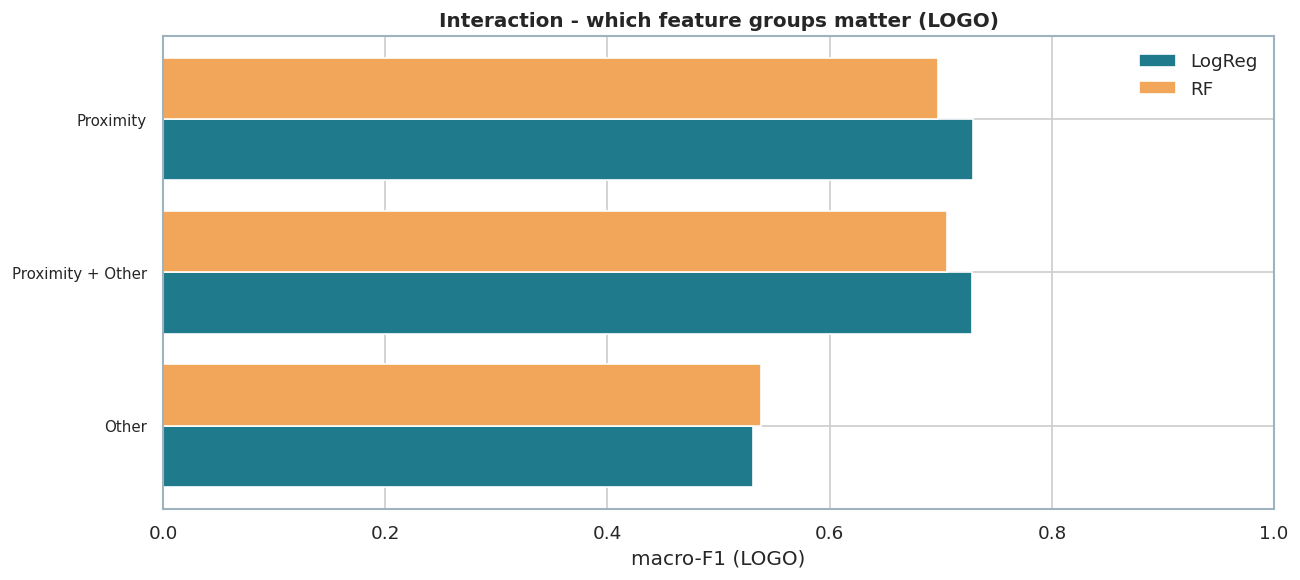

In [23]:
# === INTERACTION — feature-group ablation (all sensor combinations, LOGO) ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.impute import SimpleImputer
from itertools import combinations
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score

PATH="/content/drive/MyDrive/thesis/data/INTERACTION_ENG/interaction_eng_features.csv"
CLASSES=["non_interaction","interaction"]
F=pd.read_csv(PATH); F=F[F["label"].isin(CLASSES)].reset_index(drop=True)
allf=[c for c in F.columns if c not in ("group","label")]

def grp(c):
    if c.startswith(("dist_","centroid","fromhome","center_dist","converge")): return "Proximity"
    if c.startswith("head_"): return "Head"
    if c.startswith("hand_"): return "Hand"
    return "Other"
GROUPS={}
for c in allf: GROUPS.setdefault(grp(c),[]).append(c)
GROUPS={k:v for k,v in GROUPS.items() if v}
print("feature groups:", {k:len(v) for k,v in GROUPS.items()})

y=F["label"].values; g=F["group"].values
def evalset(feats, name):
    X=F[feats].apply(pd.to_numeric,errors="coerce").values; A=[]
    clf=(LogisticRegression(max_iter=2000,class_weight="balanced") if name=="LogReg"
         else RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",random_state=0,n_jobs=-1))
    for tr,te in LeaveOneGroupOut().split(X,y,g):
        m=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),clone(clf))
        m.fit(X[tr],y[tr]); p=m.predict(X[te])
        A.append((accuracy_score(y[te],p),f1_score(y[te],p,average="macro",zero_division=0)))
    a,f=np.mean(A,0); return a,f

keys=list(GROUPS); rows=[]
for r in range(1,len(keys)+1):
    for combo in combinations(keys,r):
        feats=sum((GROUPS[k] for k in combo),[])
        la,lf=evalset(feats,"LogReg"); ra,rf_=evalset(feats,"RF")
        rows.append([" + ".join(combo), len(feats), la, lf, ra, rf_])
res=pd.DataFrame(rows,columns=["features","n","LR_acc","LR_F1","RF_acc","RF_F1"]).sort_values("LR_F1",ascending=False)
print("\nINTERACTION - feature-group ablation (LOGO):")
print(res.round(3).to_string(index=False))

fig,ax=plt.subplots(figsize=(11,5))
r2=res.sort_values("LR_F1"); xp=np.arange(len(r2))
ax.barh(xp-0.2, r2["LR_F1"], 0.4, color="#1F7A8C", label="LogReg")
ax.barh(xp+0.2, r2["RF_F1"], 0.4, color="#F2A65A", label="RF")
ax.set_yticks(xp); ax.set_yticklabels(r2["features"],fontsize=9)
ax.set_xlabel("macro-F1 (LOGO)"); ax.set_xlim(0,1); ax.legend(frameon=False)
ax.set_title("Interaction - which feature groups matter (LOGO)")
plt.tight_layout(); plt.show()

## 5.2 · Depp Dive of the Winner Model (accuracy + honest (leave-one-out, LOGO) feature importance + confusion matrix)

proximity features: ['dist_close_mean', 'dist_close_min', 'dist_mid_mean', 'dist_far_mean', 'dist_disp_mean', 'dist_disp_std', 'centroid_speed']

Proximity-only: acc 0.711 | macro-F1 0.711

leave-one-out importance (macro-F1 drop when the feature is removed, LOGO):
        feature  f1_drop
  dist_mid_mean   0.0028
  dist_far_mean   0.0012
 dist_close_min   0.0012
  dist_disp_std   0.0004
 dist_disp_mean  -0.0005
 centroid_speed  -0.0033
dist_close_mean  -0.0034


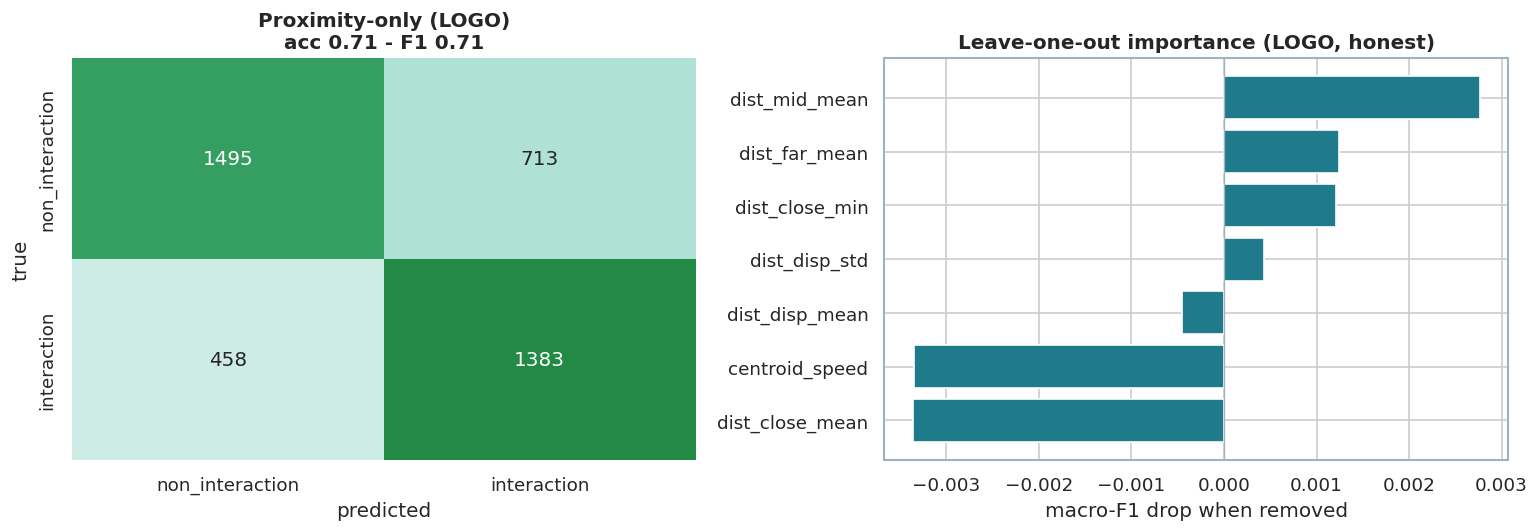

In [ ]:
# === INTERACTION — deep dive on the winning PROXIMITY-only model ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

PATH="/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/interaction_eng_features.csv"
CLASSES=["non_interaction","interaction"]
F=pd.read_csv(PATH); F=F[F["label"].isin(CLASSES)].reset_index(drop=True)
PROX=[c for c in F.columns if c.startswith(("dist_","centroid","fromhome","center_dist","converge"))]
y=F["label"].values; g=F["group"].values
print("proximity features:", PROX)

def logo_pred(feats):
    X=F[feats].fillna(0).values; yt,yp=[],[]
    for tr,te in LeaveOneGroupOut().split(X,y,g):
        m=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,class_weight="balanced"))
        m.fit(X[tr],y[tr]); yt+=list(y[te]); yp+=list(m.predict(X[te]))
    return np.array(yt),np.array(yp)

yt,yp=logo_pred(PROX); base_f1=f1_score(yt,yp,average="macro"); base_acc=accuracy_score(yt,yp)
print(f"\nProximity-only: acc {base_acc:.3f} | macro-F1 {base_f1:.3f}")

imp=[]
for f in PROX:
    yt2,yp2=logo_pred([c for c in PROX if c!=f])
    imp.append((f, base_f1 - f1_score(yt2,yp2,average="macro")))
imp=pd.DataFrame(imp,columns=["feature","f1_drop"]).sort_values("f1_drop",ascending=False)
print("\nleave-one-out importance (macro-F1 drop when the feature is removed, LOGO):")
print(imp.round(4).to_string(index=False))

fig,ax=plt.subplots(1,2,figsize=(13,4.6))
cm=confusion_matrix(yt,yp,labels=CLASSES); cmn=cm/cm.sum(1,keepdims=True)
sns.heatmap(cmn,annot=cm,fmt="d",cmap="BuGn",cbar=False,vmin=0,vmax=1,
            xticklabels=CLASSES,yticklabels=CLASSES,annot_kws={"fontsize":12},ax=ax[0])
ax[0].set_title(f"Proximity-only (LOGO)\nacc {base_acc:.2f} - F1 {base_f1:.2f}")
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true")
t=imp.sort_values("f1_drop")
ax[1].barh(t["feature"],t["f1_drop"],color="#1F7A8C")
ax[1].axvline(0,color="#9FB3BE",lw=0.8)
ax[1].set_title("Leave-one-out importance (LOGO, honest)"); ax[1].set_xlabel("macro-F1 drop when removed")
plt.tight_layout(); plt.show()

  n  added feature           LOGO macro-F1
  1  dist_close_mean                 0.707
  2  dist_mid_mean                   0.720
  3  hand_freq_max                   0.721
  4  head_antiface                   0.721
  5  hand_coord                      0.720
  6  head_freq_mean                  0.720
  7  dist_far_mean                   0.720
  8  hand_freq_mean                  0.719
  9  head_power_mean                 0.717
 10  head_freq_max                   0.717

peak: macro-F1 0.721 at 3 features -> ['dist_close_mean', 'dist_mid_mean', 'hand_freq_max']


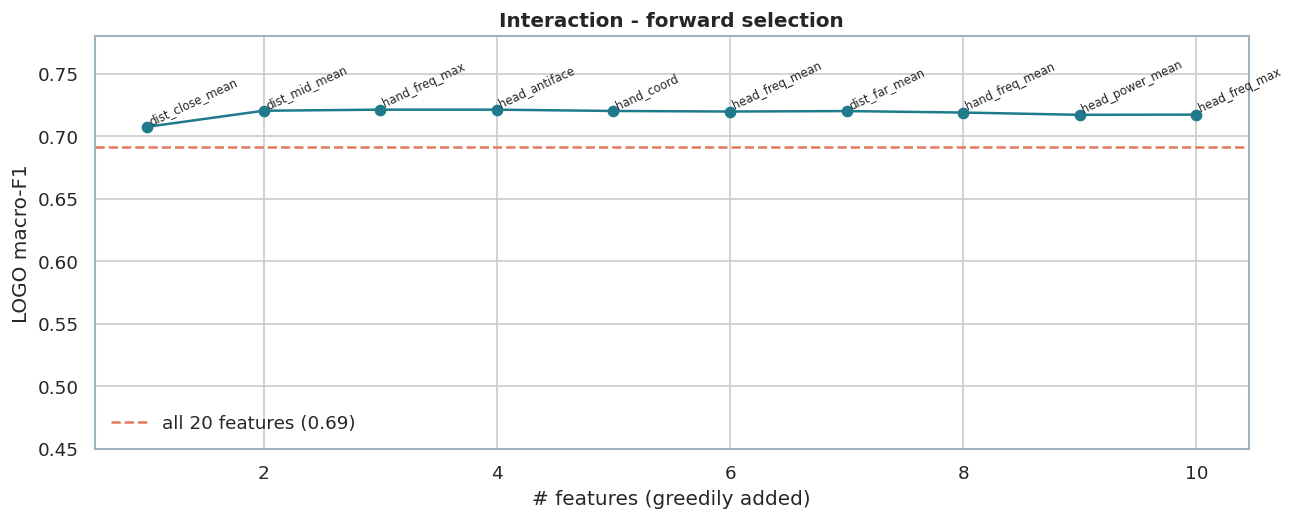

In [ ]:
# === INTERACTION — forward feature selection (LOGO): how few features do we need? ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

PATH="/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/interaction_eng_features.csv"
CLASSES=["non_interaction","interaction"]
F=pd.read_csv(PATH); F=F[F["label"].isin(CLASSES)].reset_index(drop=True)
allf=[c for c in F.columns if c not in ("group","label")]
y=F["label"].values; g=F["group"].values; cv=list(LeaveOneGroupOut().split(F[allf].values,y,g))

def f1_of(feats):
    X=F[feats].apply(pd.to_numeric,errors="coerce").values; A=[]
    for tr,te in cv:
        m=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),
                        LogisticRegression(max_iter=2000,class_weight="balanced"))
        m.fit(X[tr],y[tr]); p=m.predict(X[te])
        A.append(f1_score(y[te],p,average="macro",zero_division=0))
    return float(np.mean(A))

selected=[]; remaining=list(allf); curve=[]
while remaining and len(selected)<10:
    best=None
    for f in remaining:
        s=f1_of(selected+[f])
        if best is None or s>best[1]: best=(f,s)
    selected.append(best[0]); remaining.remove(best[0]); curve.append((len(selected),best[0],best[1]))

print(f"{'n':>3}  {'added feature':22s} {'LOGO macro-F1':>14}")
for n,f,s in curve: print(f"{n:>3}  {f:22s} {s:>14.3f}")
bn=max(curve,key=lambda r:r[2]); print(f"\npeak: macro-F1 {bn[2]:.3f} at {bn[0]} features -> {[c[1] for c in curve[:bn[0]]]}")

xs=[c[0] for c in curve]; ys=[c[2] for c in curve]
plt.figure(figsize=(11,4.5)); plt.plot(xs,ys,marker="o",color="#1F7A8C")
plt.axhline(0.691,ls="--",c="#E07A5F",label="all 20 features (0.69)")
for n,f,s in curve: plt.annotate(f,(n,s),fontsize=7,rotation=25,ha="left",va="bottom")
plt.xlabel("# features (greedily added)"); plt.ylabel("LOGO macro-F1")
plt.title("Interaction - forward selection"); plt.legend(frameon=False); plt.ylim(0.45,0.78)
plt.tight_layout(); plt.show()

## 6 · Explainability (permutation importance + sensor rollup)

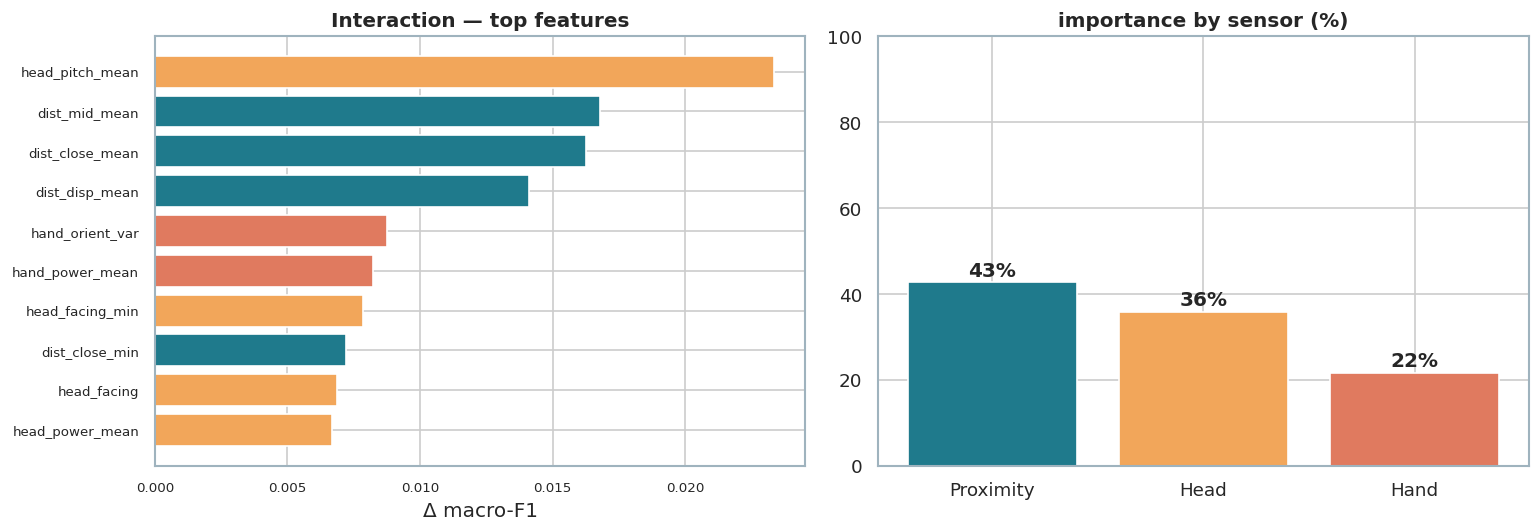

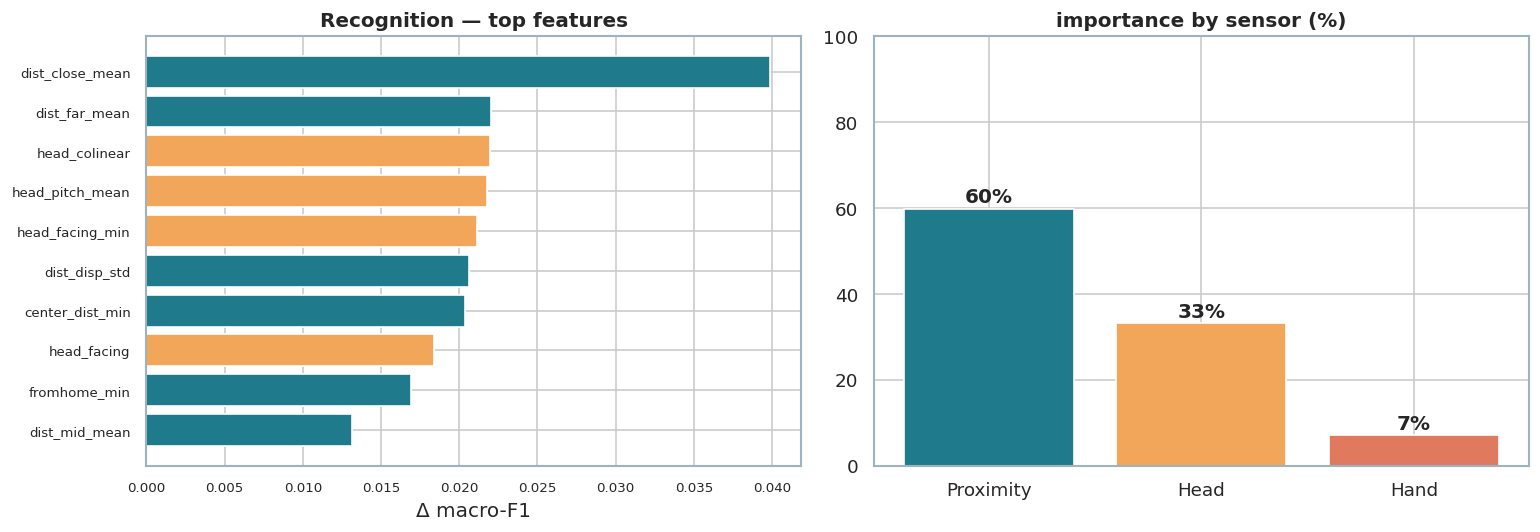

In [ ]:
# === EXPLAINABILITY ===
from sklearn.inspection import permutation_importance
def sensor(f):
    if f.startswith(("dist_","centroid","fromhome","center_dist","converge")): return "Proximity"
    if f.startswith("head_"): return "Head"
    if f.startswith("hand_"): return "Hand"
    return "Other"
pal={"Proximity":TEAL,"Head":AMBER,"Hand":CORAL,"Other":SLATE}
for task in ["interaction","recognition"]:
    X,y,g,feats=prep(DATA[(task,"eng")],CLASSES[task])
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.3,stratify=y,random_state=0)
    rf=model("RF").fit(Xtr,ytr)
    perm=permutation_importance(rf,Xte,yte,n_repeats=10,random_state=0,scoring="f1_macro")
    imp=pd.DataFrame({"feature":feats,"imp":perm.importances_mean,"sensor":[sensor(f) for f in feats]}).sort_values("imp",ascending=False)
    fig,ax=plt.subplots(1,2,figsize=(13,4.6)); top=imp.head(10)[::-1]
    ax[0].barh(top["feature"],top["imp"],color=[pal[s] for s in top["sensor"]])
    ax[0].set_title(f"{task.title()} — top features"); ax[0].set_xlabel("Δ macro-F1"); ax[0].tick_params(labelsize=8)
    roll=imp.groupby("sensor")["imp"].apply(lambda s:s[s>0].sum()); roll=(roll/roll.sum()*100).sort_values(ascending=False)
    ax[1].bar(roll.index,roll.values,color=[pal[s] for s in roll.index]); ax[1].set_ylim(0,100); ax[1].set_title("importance by sensor (%)")
    for i,v in enumerate(roll.values): ax[1].text(i,v+1.5,f"{v:.0f}%",ha="center",fontweight="bold")
    plt.tight_layout(); plt.show()

## 7 · Data imbalance solutions (recognition)

    strategy  macroF1  co_building  co_merging  conversation
class_weight    0.633        0.716       0.409         0.775
       SMOTE    0.619        0.698       0.386         0.773
  oversample    0.632        0.715       0.407         0.774
 undersample    0.655        0.719       0.475         0.772


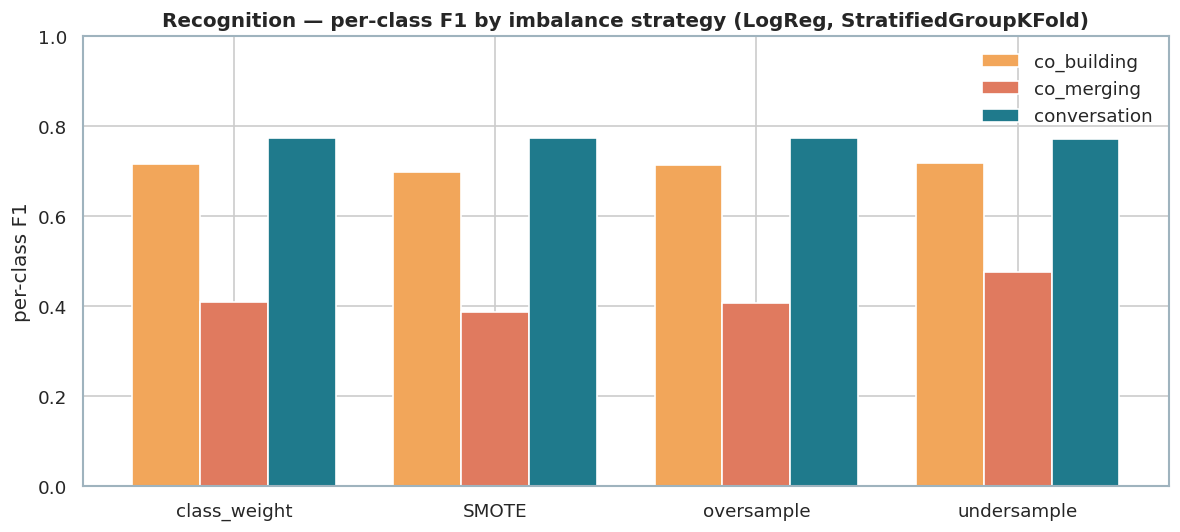

In [ ]:
# === IMBALANCE ===
try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError:
    import subprocess,sys; subprocess.run([sys.executable,"-m","pip","install","-q","imbalanced-learn"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
X,y,g,_=prep(DATA[("recognition","eng")],CLASSES["recognition"]); REC=CLASSES["recognition"]
LR=lambda **k: LogisticRegression(max_iter=2000,**k)
strategies={
 "class_weight":ImbPipeline([("sc",StandardScaler()),("clf",LR(class_weight="balanced"))]),
 "SMOTE":       ImbPipeline([("sc",StandardScaler()),("s",SMOTE(random_state=0)),("clf",LR())]),
 "oversample":  ImbPipeline([("sc",StandardScaler()),("o",RandomOverSampler(random_state=0)),("clf",LR())]),
 "undersample": ImbPipeline([("sc",StandardScaler()),("u",RandomUnderSampler(random_state=0)),("clf",LR())]),
}
rows=[]
for name,pipe in strategies.items():
    yt,yp=[],[]
    for tr,te in StratifiedGroupKFold(5,shuffle=True,random_state=0).split(X,y,g):
        pipe.fit(X[tr],y[tr]); yt+=list(y[te]); yp+=list(pipe.predict(X[te]))
    yt,yp=np.array(yt),np.array(yp)
    rows.append([name,f1_score(yt,yp,average="macro")]+[f1_score(yt,yp,labels=[c],average="macro") for c in REC])
res=pd.DataFrame(rows,columns=["strategy","macroF1"]+REC); print(res.round(3).to_string(index=False))
fig,ax=plt.subplots(figsize=(10,4.6)); xp=np.arange(len(res)); w=0.26
for k,(c,col) in enumerate(zip(REC,[AMBER,CORAL,TEAL])): ax.bar(xp+(k-1)*w,res[c],w,label=c,color=col)
ax.set_xticks(xp); ax.set_xticklabels(res["strategy"]); ax.set_ylim(0,1); ax.set_ylabel("per-class F1"); ax.legend(frameon=False)
ax.set_title("Recognition — per-class F1 by imbalance strategy (LogReg, StratifiedGroupKFold)")
plt.tight_layout(); plt.show()

## 8 · Stratification — LOGO vs StratifiedGroupKFold

        case  LOGO  StratGroupKFold
int · LogReg 0.691            0.690
    int · RF 0.657            0.651
rec · LogReg 0.641            0.633
    rec · RF 0.348            0.326


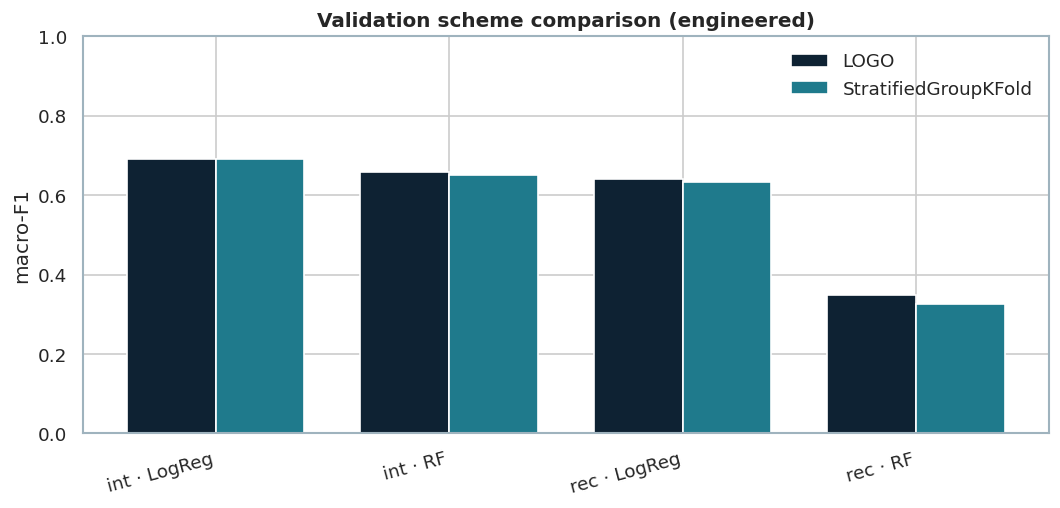

In [ ]:
# === STRATIFICATION ===
rows=[]
for task in ["interaction","recognition"]:
    for name in ["LogReg","RF"]:
        _,_,_,fl=run(DATA[(task,"eng")],CLASSES[task],name,"logo")
        _,_,_,fs=run(DATA[(task,"eng")],CLASSES[task],name,"sgkf")
        rows.append([task[:3]+" · "+name,fl,fs])
comp=pd.DataFrame(rows,columns=["case","LOGO","StratGroupKFold"]); print(comp.round(3).to_string(index=False))
fig,ax=plt.subplots(figsize=(9,4.4)); xp=np.arange(len(comp)); w=0.38
ax.bar(xp-w/2,comp["LOGO"],w,label="LOGO",color=INK); ax.bar(xp+w/2,comp["StratGroupKFold"],w,label="StratifiedGroupKFold",color=TEAL)
ax.set_xticks(xp); ax.set_xticklabels(comp["case"],rotation=15,ha="right"); ax.set_ylim(0,1)
ax.set_ylabel("macro-F1"); ax.legend(frameon=False); ax.set_title("Validation scheme comparison (engineered)")
plt.tight_layout(); plt.show()

## 9 · Mutual-gaze test — does shared gaze help?


##### INTERACTION #####  gaze: ['head_antiface', 'head_colinear', 'head_facing_min']
  [logo] base 0.692 -> +gaze 0.691  (Δ -0.001)  per-class +gaze: non_interaction:0.69, interaction:0.69
  [sgkf] base 0.691 -> +gaze 0.690  (Δ -0.001)  per-class +gaze: non_interaction:0.70, interaction:0.68
  gaze spread across classes: {'head_antiface': 0.0, 'head_colinear': 0.002, 'head_facing_min': 0.003} (~0 => cannot separate)

##### RECOGNITION #####  gaze: ['head_antiface', 'head_colinear', 'head_facing_min']
  [logo] base 0.647 -> +gaze 0.641  (Δ -0.005)  per-class +gaze: co_building:0.71, co_merging:0.44, conversation:0.78
  [sgkf] base 0.637 -> +gaze 0.633  (Δ -0.004)  per-class +gaze: co_building:0.72, co_merging:0.41, conversation:0.77
  gaze spread across classes: {'head_antiface': 0.0, 'head_colinear': 0.003, 'head_facing_min': 0.007} (~0 => cannot separate)


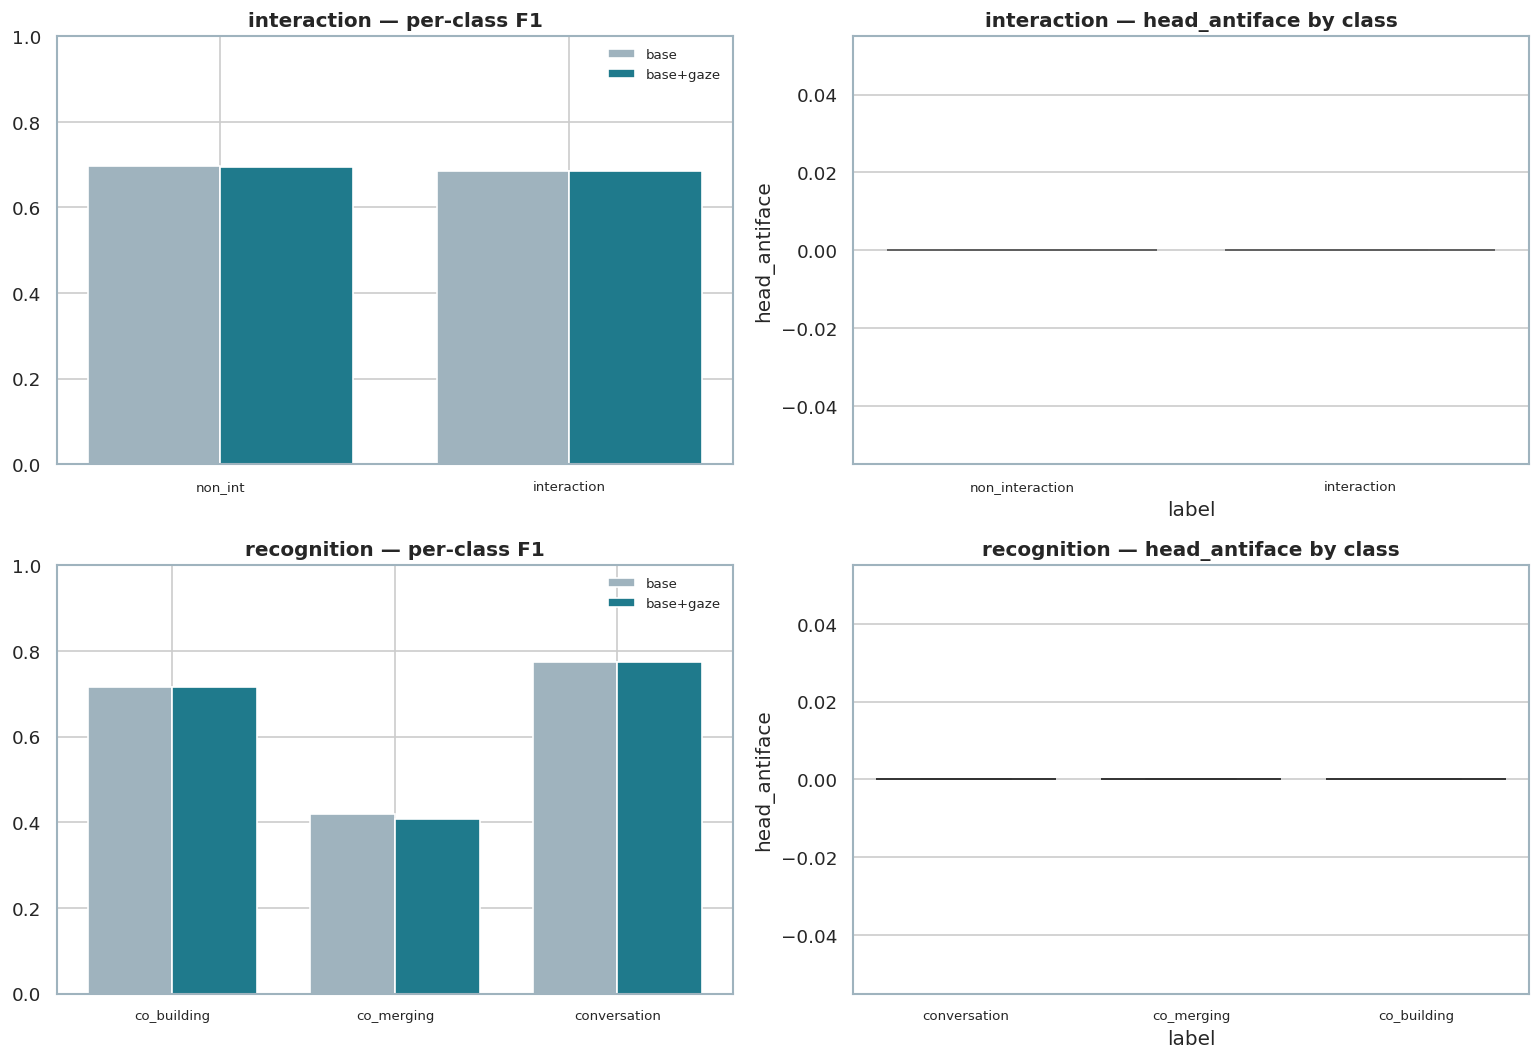

In [ ]:
# === GAZE TEST: base vs base+gaze (both tasks) ===
GAZE=["head_antiface","head_colinear","head_facing_min"]
fig,axes=plt.subplots(2,2,figsize=(13,9))
for r,task in enumerate(["interaction","recognition"]):
    F=DATA[(task,"eng")]; classes=CLASSES[task]; F=F[F["label"].isin(classes)].reset_index(drop=True)
    present=[c for c in GAZE if c in F.columns]
    if not present: print(f"[{task}] no gaze cols — re-run build cell"); continue
    base=[c for c in F.columns if c not in ("group","label")+tuple(present)]
    def ev(feats,cv):
        X=F[feats].fillna(0).values; y=F["label"].values; g=F["group"].values; yt,yp=[],[]
        for tr,te in splitter(cv).split(X,y,g):
            m=model("LogReg"); m.fit(X[tr],y[tr]); yt+=list(y[te]); yp+=list(m.predict(X[te]))
        yt,yp=np.array(yt),np.array(yp)
        return f1_score(yt,yp,average="macro"),{c:f1_score(yt,yp,labels=[c],average="macro") for c in classes}
    print(f"\n##### {task.upper()} #####  gaze: {present}")
    for cv in ["logo","sgkf"]:
        m0,p0=ev(base,cv); m1,p1=ev(base+present,cv)
        print(f"  [{cv:4s}] base {m0:.3f} -> +gaze {m1:.3f}  (Δ {m1-m0:+.3f})  per-class +gaze: "+
              ", ".join(f"{c}:{p1[c]:.2f}" for c in classes))
    means=F.groupby("label")[present].mean(); spread={c:round(float((means.max()-means.min())[c]),3) for c in present}
    print("  gaze spread across classes:",spread,"(~0 => cannot separate)")
    m0,p0=ev(base,"sgkf"); m1,p1=ev(base+present,"sgkf")
    ax=axes[r,0]; xp=np.arange(len(classes)); w=0.38
    ax.bar(xp-w/2,[p0[c] for c in classes],w,label="base",color=SLATE)
    ax.bar(xp+w/2,[p1[c] for c in classes],w,label="base+gaze",color=TEAL)
    ax.set_xticks(xp); ax.set_xticklabels([c.replace("_interaction","_int") for c in classes],fontsize=8)
    ax.set_ylim(0,1); ax.set_title(f"{task} — per-class F1"); ax.legend(frameon=False,fontsize=8)
    sns.boxplot(data=F,x="label",y="head_antiface",hue="label",legend=False,
                palette=[AMBER,CORAL,TEAL][:len(classes)],ax=axes[r,1])
    axes[r,1].set_title(f"{task} — head_antiface by class"); axes[r,1].tick_params(axis="x",labelsize=8)
plt.tight_layout(); plt.show()

## Summary

Everything above is computed from your raw data with your own feature code (+ gaze), so it's
internally consistent and reproducible. Read the gaze spread in §9: if it's ~0, the uncalibrated
earable magnetometer can't resolve who-faces-whom — a clean sensor-limitation finding for the thesis.